In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor

In [2]:
# Carregando o dataset
df = pd.read_csv('../project_II/dataset_final_medicamentos.csv')

# Visualizando as primeiras linhas
df.head()

,idMedicamentos,nomeMedicamento,preco,marca,quantidade,dosagem,substancia,substancia_limpa,avaliacao,dataPreco,...,sem_catarro,sem_catarro_associada_a_gripes_e_resfriados_ou_a_inalacao_de_agentes_irritantes,sob_os_seios_ou_em_outras_areas_da_pele_que_sofrem_atrito_em_criancas_e_adultos,teniase,tosse_e_dor_muscular_associadas_a_gripes_e_resfriados,tricuriase,urticarias,vulvar_e_peniana,vomito_e_distensao_abdominal,ulcera_cutanea
0,8,Pastilha Ciflogex Diet Sabor Menta 12 unidades,12.90,2,12un,3MG,Cloridrato de Benzidamina,cloridrato de benzidamina,4.8,2025-10-06,...,0,0,0,0,0,0,0,0,0,0
1,9,Pastilha Ciflogex Sabor Mel e Limão 12 unidades,12.90,2,12un,3MG,Cloridrato de Benzidamina,cloridrato de benzidamina,4.5,2025-10-06,...,0,0,0,0,0,0,0,0,0,0
2,10,Pastilha Ciflogex Sabor Menta e Limão 12 unidades,12.90,2,12un,3MG,Cloridrato de Benzidamina,cloridrato de benzidamina,3.2,2025-10-06,...,0,0,0,0,0,0,0,0,0,0
3,11,Pastilha Flogoral Sabor Menta 4 unidades,6.45,3,4un,3MG,Cloridrato de Benzidamina,cloridrato de benzidamina,3.6,2025-10-06,...,0,0,0,0,0,0,0,0,0,0
4,12,Pastilha Flogoral Sabor Menta 12 unidades,18.09,3,12un,3MG,Cloridrato de Benzidamina,cloridrato de benzidamina,3.2,2025-10-06,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2250 entries, 0 to 2249
Columns: 222 entries, idMedicamentos to ulcera_cutanea
dtypes: float64(2), int64(213), object(7)
memory usage: 3.8+ MB


In [4]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,idMedicamentos,preco,marca,avaliacao,idMedicamento_base,acne_vulgar,afeccoes_cutaneas,aftas_e_outras_inflamacoes_da_mucosa_da_boca,aftas_e_outras_inflamacoes_na_mucosa_da_boca,alivio_da_azia,...,sem_catarro,sem_catarro_associada_a_gripes_e_resfriados_ou_a_inalacao_de_agentes_irritantes,sob_os_seios_ou_em_outras_areas_da_pele_que_sofrem_atrito_em_criancas_e_adultos,teniase,tosse_e_dor_muscular_associadas_a_gripes_e_resfriados,tricuriase,urticarias,vulvar_e_peniana,vomito_e_distensao_abdominal,ulcera_cutanea
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.0,2250.0,2250.0,2250.0,2250.0,...,2250.000000,2250.0,2250.0,2250.0,2250.0,2250.0,2250.0,2250.0,2250.0,2250.0
mean,2019.060000,25.454422,66.404000,4.022311,159.060000,0.0,0.0,0.0,0.0,0.0,...,0.020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,1287.964695,20.094397,39.692279,0.628605,84.286878,0.0,0.0,0.0,0.0,0.0,...,0.140031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,8.000000,0.000000,2.000000,2.600000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,903.250000,11.302500,32.000000,3.500000,88.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,1988.500000,19.735000,59.000000,4.100000,151.500000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,3091.750000,34.475000,92.000000,4.500000,233.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,4190.000000,138.650000,145.000000,5.000000,309.000000,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Identificando a variável alvo e as 3 mais correlacionadas (apenas colunas numéricas)
target = 'preco'  # Ajuste conforme o nome correto da variável alvo
numeric_df = df.select_dtypes(include=np.number)
correlations = numeric_df.corr()[target].abs().sort_values(ascending=False)
top_features = correlations.index[1:4]  # 3 variáveis mais correlacionadas
print('Variável alvo:', target)
print('Variáveis mais correlacionadas:', list(top_features))

Variável alvo: preco
Variáveis mais correlacionadas: ['congestao_nasal', 'mucosa_nasal_ressecada_e_irritada', 'marca']


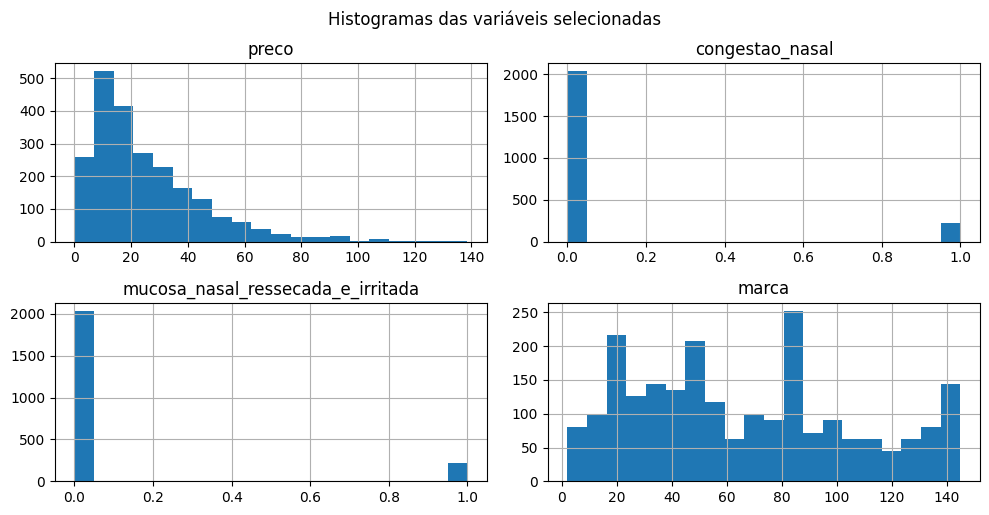

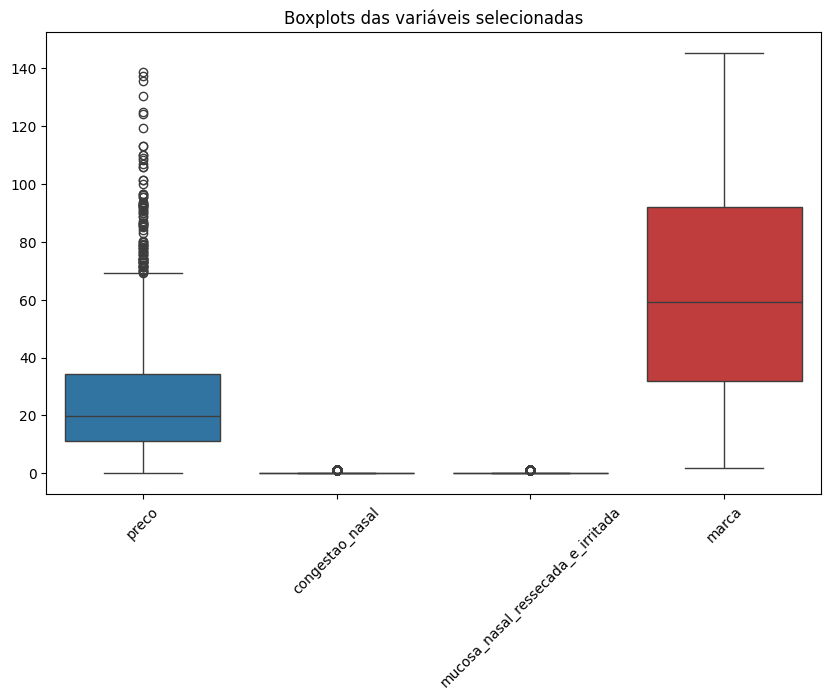

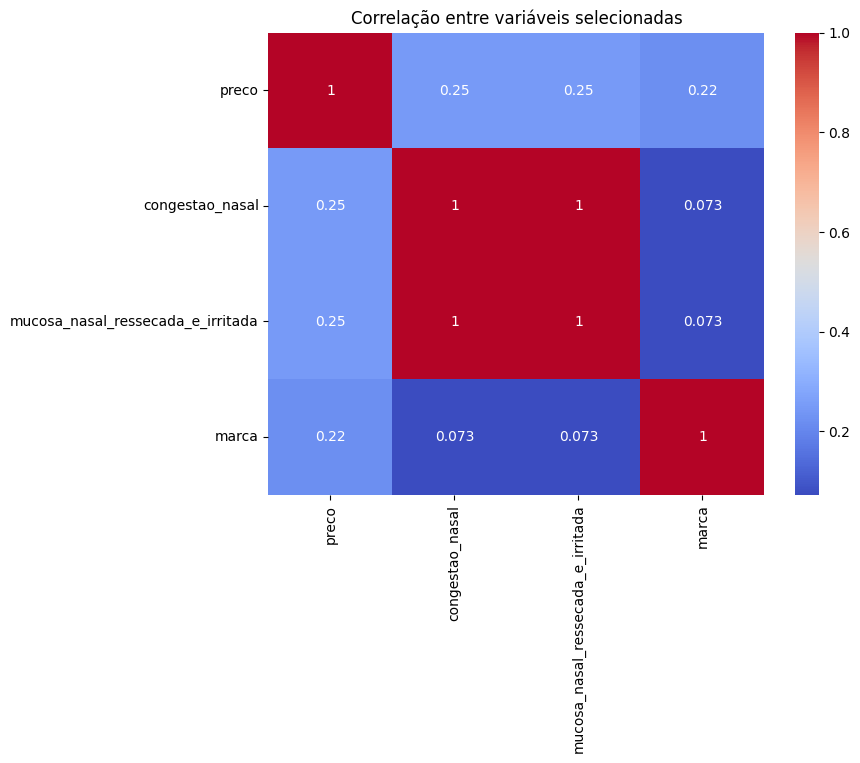

In [32]:
# Histogramas das variáveis selecionadas
selected_vars = [target] + list(top_features)
axes = df[selected_vars].hist(figsize=(10,6), bins=20)
plt.suptitle('Histogramas das variáveis selecionadas', y=0.85)  # aumenta ainda mais o espaço acima dos gráficos
plt.tight_layout(rect=[0, 0, 1, 0.88])  # reserva mais espaço para o título
plt.savefig('imagens/histogramas_selected_vars.png', bbox_inches='tight')
plt.show()

# Boxplots das variáveis selecionadas
plt.figure(figsize=(10,6))
sns.boxplot(data=df[selected_vars])
plt.xticks(rotation=45)
plt.title('Boxplots das variáveis selecionadas')
plt.savefig('imagens/boxplots_selected_vars.png')
plt.show()

# Heatmap de correlação das variáveis selecionadas
plt.figure(figsize=(8,6))
sns.heatmap(df[selected_vars].corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre variáveis selecionadas')
plt.savefig('imagens/heatmap_correlation.png')
plt.show()

In [8]:
# Selecionando variáveis preditoras e alvo
X = numeric_df.drop(columns=[target])
y = numeric_df[target]

# Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o modelo de Árvore de Decisão
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Fazendo previsões
y_pred = model.predict(X_test)

# Avaliando o modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('MAE:', mae)
print('R²:', r2)

MSE: 71.59088911111111
MAE: 5.3721555555555565
R²: 0.8205010430473849


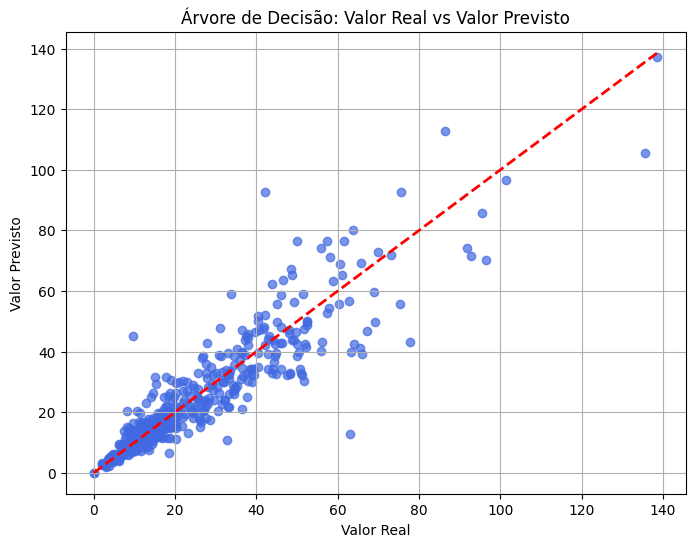

In [9]:
# Gráfico de dispersão: valores reais vs previstos
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Árvore de Decisão: Valor Real vs Valor Previsto')
plt.grid(True)
plt.savefig('imagens/decision_tree_real_vs_predicted.png')
plt.show()

In [10]:
# Treinando e avaliando o modelo Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('Random Forest - MSE:', mse_rf)
print('Random Forest - MAE:', mae_rf)
print('Random Forest - R²:', r2_rf)

Random Forest - MSE: 48.91982359544441
Random Forest - MAE: 4.761815333333331
Random Forest - R²: 0.8773439271572707


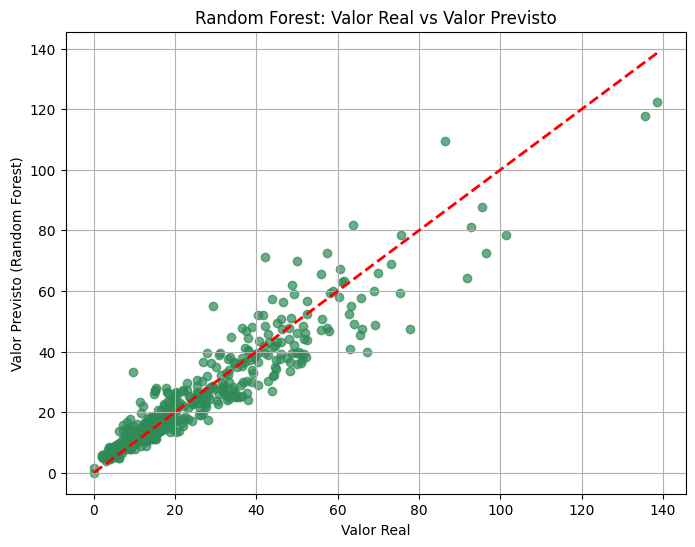

In [11]:
# Visualização dos resultados do Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto (Random Forest)')
plt.title('Random Forest: Valor Real vs Valor Previsto')
plt.grid(True)
plt.savefig('imagens/random_forest_real_vs_predicted.png')
plt.show()

In [12]:
# KNN ajustado extra: seleção de variáveis, normalização e busca de hiperparâmetros
selected_features = list(top_features)
X_selected = numeric_df[selected_features]
y_selected = numeric_df[target]

# Divisão em treino e teste
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42
 )

# Normalização dos dados
scaler_minmax = MinMaxScaler()
X_train_sel_scaled = scaler_minmax.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_minmax.transform(X_test_sel)

# Busca dos melhores hiperparâmetros para o KNN
param_grid_knn = {
    'n_neighbors': range(2, 21),
    'p': [1, 2]
}
grid_knn_sel = GridSearchCV(
    KNeighborsRegressor(), param_grid_knn, cv=5, scoring='r2'
 )
grid_knn_sel.fit(X_train_sel_scaled, y_train_sel)
best_params_sel = grid_knn_sel.best_params_

# Treinamento e avaliação do modelo KNN com os melhores parâmetros
knn_model_sel = KNeighborsRegressor(
    n_neighbors=best_params_sel['n_neighbors'],
    p=best_params_sel['p']
 )
knn_model_sel.fit(X_train_sel_scaled, y_train_sel)
y_pred_knn_sel = knn_model_sel.predict(X_test_sel_scaled)

# Métricas de avaliação
mse_knn_sel = mean_squared_error(y_test_sel, y_pred_knn_sel)
mae_knn_sel = mean_absolute_error(y_test_sel, y_pred_knn_sel)
r2_knn_sel = r2_score(y_test_sel, y_pred_knn_sel)

print('KNN (ajustado extra) - MSE:', mse_knn_sel)
print('KNN (ajustado extra) - MAE:', mae_knn_sel)
print('KNN (ajustado extra) - R²:', r2_knn_sel)
print('Melhor k:', best_params_sel['n_neighbors'], '| Distância p:', best_params_sel['p'])

KNN (ajustado extra) - MSE: 219.38613278395064
KNN (ajustado extra) - MAE: 9.84307777777778
KNN (ajustado extra) - R²: 0.44993584388274854
Melhor k: 6 | Distância p: 1


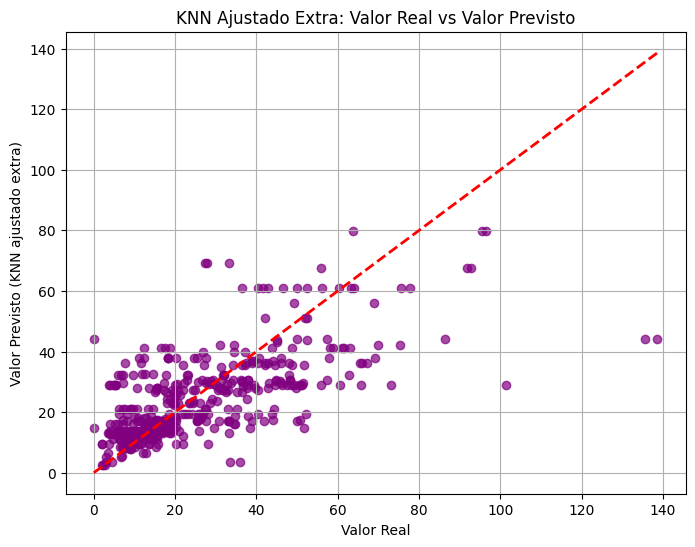

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_sel, y_pred_knn_sel, alpha=0.7, color='purple')
plt.plot([y_test_sel.min(), y_test_sel.max()], [y_test_sel.min(), y_test_sel.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto (KNN ajustado extra)')
plt.title('KNN Ajustado Extra: Valor Real vs Valor Previsto')
plt.grid(True)
plt.savefig('imagens/knn_adjusted_real_vs_predicted.png')
plt.show()

In [14]:
# Comparação final dos três modelos: Árvore de Decisão, Random Forest e KNN Ajustado Extra
metrics_df = pd.DataFrame({
    'Modelo': ['Árvore de Decisão', 'Random Forest', 'KNN Ajustado Extra'],
    'MSE': [mse, mse_rf, mse_knn_sel],
    'MAE': [mae, mae_rf, mae_knn_sel],
    'R²': [r2, r2_rf, r2_knn_sel]
})
print(metrics_df)


               Modelo         MSE       MAE        R²
0   Árvore de Decisão   71.590889  5.372156  0.820501
1       Random Forest   48.919824  4.761815  0.877344
2  KNN Ajustado Extra  219.386133  9.843078  0.449936


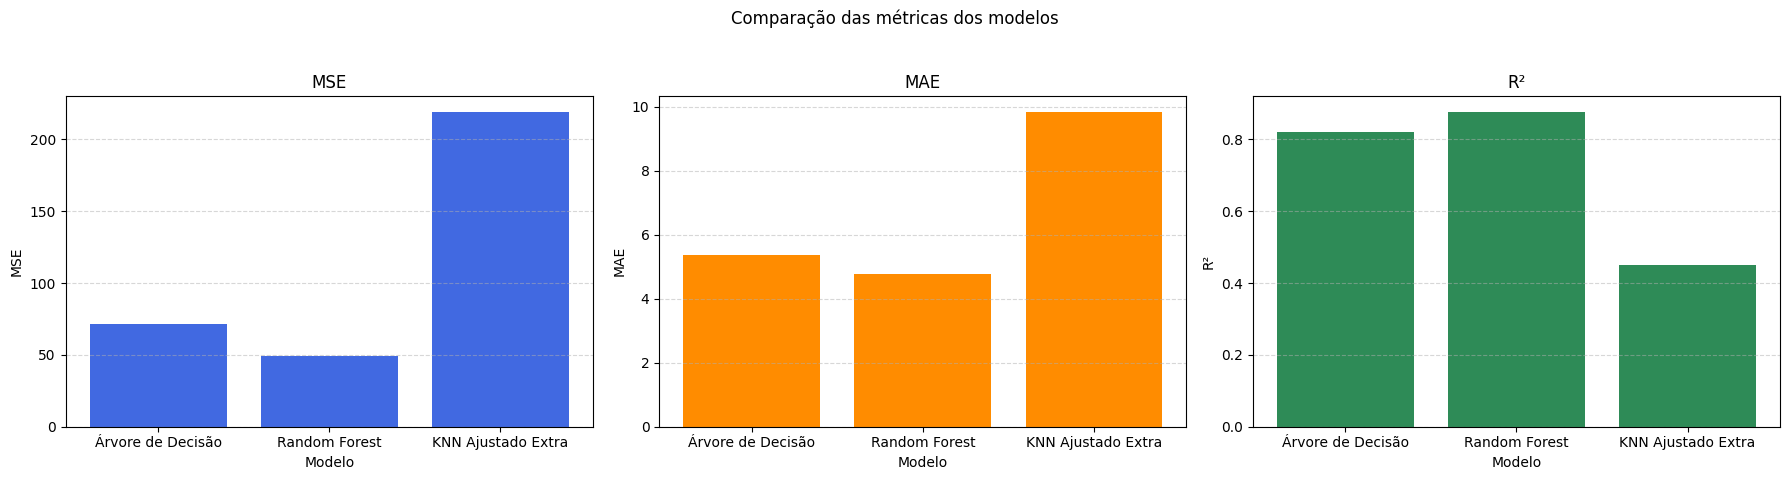

In [15]:
# Gráfico comparativo melhorado: MSE, MAE e R² em escalas separadas
fig, axs = plt.subplots(1, 3, figsize=(18,5))
metrics = ['MSE', 'MAE', 'R²']
colors = ['royalblue', 'darkorange', 'seagreen']
for i, metric in enumerate(metrics):
    axs[i].bar(metrics_df['Modelo'], metrics_df[metric], color=colors[i])
    axs[i].set_title(metric)
    axs[i].set_ylabel(metric)
    axs[i].set_xlabel('Modelo')
    axs[i].grid(True, axis='y', linestyle='--', alpha=0.5)
plt.suptitle('Comparação das métricas dos modelos')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('imagens/model_comparison_metrics.png')
plt.show()